In [30]:
import numpy as np
import pandas as pd
from pathlib import Path
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
DATA_PROCESSED = ROOT / "data" / "processed"

signals = pd.read_csv(DATA_PROCESSED / "signals.csv", 
                      index_col=0, parse_dates=True)

In [31]:
# HMM learns from slope, vrp and realised volatility
features = signals[["vrp", "slope", "rv_30"]].dropna()

# standardise for hmm to learn from standard scales
scaler = StandardScaler()
X = scaler.fit_transform(features)

print("Feature matrix shape:", X.shape)
print("\nMeans (should be ~0 after scaling):", X.mean(axis=0).round(4))
print("Stds  (should be ~1 after scaling):", X.std(axis=0).round(4))

Feature matrix shape: (4964, 3)

Means (should be ~0 after scaling): [ 0. -0. -0.]
Stds  (should be ~1 after scaling): [1. 1. 1.]


In [32]:
# 3 hidden states: calm, stressed, crisis
model = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X)

# Decode most likely state sequence
hidden_states = model.predict(X)
features["regime"] = hidden_states

print("Training complete.")
print(f"Converged: {model.monitor_.converged}")
print(f"\nState counts:")
for s in range(3):
    pct = (hidden_states == s).mean() * 100
    print(f"  State {s}: {pct:.1f}% of days")

Training complete.
Converged: True

State counts:
  State 0: 34.4% of days
  State 1: 11.9% of days
  State 2: 53.6% of days


In [33]:
print("State characteristics:\n")
for s in range(3):
    mask = features["regime"] == s
    mean_vrp   = features.loc[mask, "vrp"].mean()
    mean_slope = features.loc[mask, "slope"].mean()
    mean_rv    = features.loc[mask, "rv_30"].mean()
    pct        = mask.mean() * 100
    print(f"State {s} ({pct:.1f}% of days)")
    print(f"  VRP mean:   {mean_vrp:.4f}")
    print(f"  Slope mean: {mean_slope:.4f}")
    print(f"  RV mean:    {mean_rv:.4f}")
    print()

State characteristics:

State 0 (34.4% of days)
  VRP mean:   0.0341
  Slope mean: 0.0886
  RV mean:    0.1826

State 1 (11.9% of days)
  VRP mean:   -0.0177
  Slope mean: 0.0078
  RV mean:    0.3853

State 2 (53.6% of days)
  VRP mean:   0.0434
  Slope mean: 0.1460
  RV mean:    0.1025



In [34]:
state_map = {2: "calm", 0: "stressed", 1: "crisis"}
features["regime_label"] = features["regime"].map(state_map)

signals = signals.join(features[["regime", "regime_label"]])

signals.to_csv(DATA_PROCESSED / "regimes.csv")
print("Saved regimes.csv")
print(signals["regime_label"].value_counts())

Saved regimes.csv
regime_label
calm        2663
stressed    1710
crisis       591
Name: count, dtype: int64


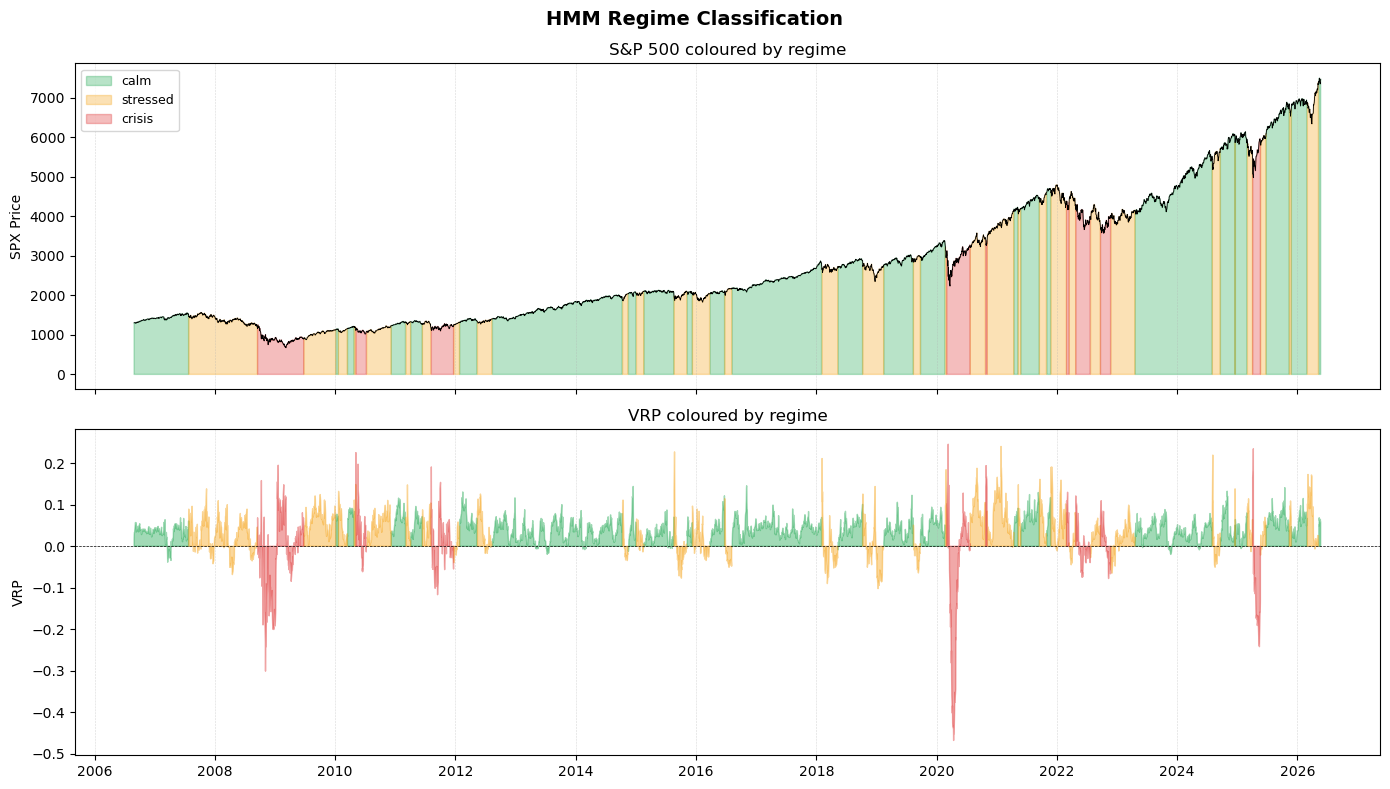

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("HMM Regime Classification", fontsize=14, fontweight="bold")

# Colour map for regimes
colors = {"calm": "#16a34a", "stressed": "#f59e0b", "crisis": "#dc2626"}

# Panel 1: SPX coloured by regime
for label, color in colors.items():
    mask = signals["regime_label"] == label
    axes[0].fill_between(signals.index, signals["spx"],
                         where=mask, color=color, alpha=0.3, label=label)
axes[0].plot(signals.index, signals["spx"], color="black", linewidth=0.6)
axes[0].set_ylabel("SPX Price")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_title("S&P 500 coloured by regime")

# Panel 2: VRP coloured by regime
for label, color in colors.items():
    mask = signals["regime_label"] == label
    axes[1].fill_between(signals.index, signals["vrp"],
                         where=mask, color=color, alpha=0.4)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("VRP")
axes[1].set_title("VRP coloured by regime")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "regimes_overview.png", dpi=150, bbox_inches="tight")
plt.show()